In [1]:
#Get data
import pandas as pd

df = pd.read_csv("../Course_Data/Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


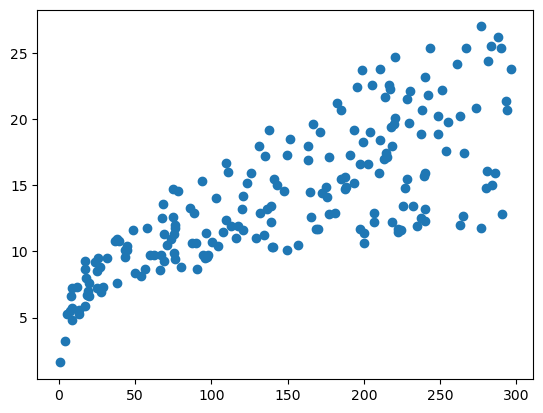

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["TV"], df["Sales"])
plt.show()

In [4]:
#Calculate model coefficients with sklearn
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array(df["TV"]).reshape(-1, 1)
y = np.array(df["Sales"])

reg = LinearRegression()

reg.fit(X,y)

print(f"Sales = {reg.intercept_} + {reg.coef_[0]} * TV")

Sales = 7.0325935491276965 + 0.047536640433019736 * TV


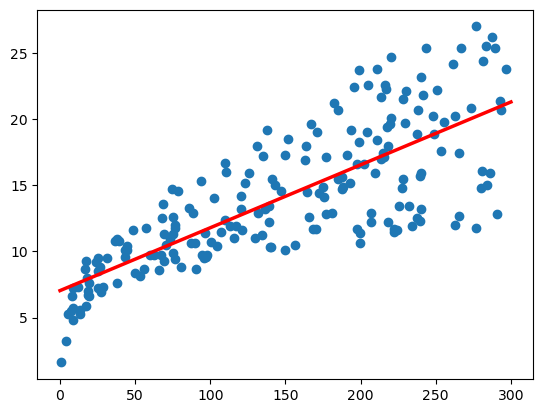

In [5]:
# Create sequence of 100 numbers from 0 to 100 
xseq = np.linspace(0, 300, num=100)
yseq = reg.intercept_ * np.ones_like(xseq) + reg.coef_[0] * xseq

# Plot regression line
plt.plot(xseq, yseq, lw=2.5, color="r");

plt.scatter(X, y)
plt.show()

In [6]:
#Use statsmodels library to calculate linear regression statistics

import statsmodels.api as sm

X = sm.add_constant(df.TV)
est = sm.OLS(df.Sales, X)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Mon, 10 Apr 2023   Prob (F-statistic):           1.47e-42
Time:                        21:19:05   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

In [7]:
X = sm.add_constant(df.Radio)
est = sm.OLS(df.Sales, X)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     98.42
Date:                Mon, 10 Apr 2023   Prob (F-statistic):           4.35e-19
Time:                        21:19:05   Log-Likelihood:                -573.34
No. Observations:                 200   AIC:                             1151.
Df Residuals:                     198   BIC:                             1157.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3116      0.563     16.542      0.0

In [8]:
X = sm.add_constant(df.Newspaper)
est = sm.OLS(df.Sales, X)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     10.89
Date:                Mon, 10 Apr 2023   Prob (F-statistic):            0.00115
Time:                        21:19:05   Log-Likelihood:                -608.34
No. Observations:                 200   AIC:                             1221.
Df Residuals:                     198   BIC:                             1227.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3514      0.621     19.876      0.0

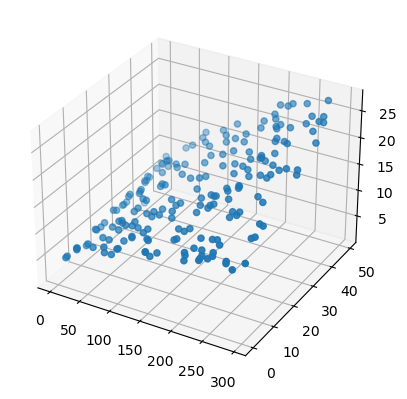

In [9]:
X = np.array(df["TV"])
Y = np.array(df["Radio"])
z = np.array(df["Sales"])

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X, Y, z)
plt.show()

In [10]:
import plotly.express as px

selected_columns = ["TV", "Radio", "Sales"]

fig = px.scatter_3d(df[selected_columns], x=selected_columns[0], y=selected_columns[1], z=selected_columns[2])

fig.update_traces(marker=dict(size=3))

fig.show()

In [11]:
X = np.array(df[["TV", "Radio"]])
y = np.array(df["Sales"])

reg = LinearRegression()

reg.fit(X,y)

print(f"Sales = {reg.intercept_} + {reg.coef_[0]} * TV + {reg.coef_[1]} * Radio")

Sales = 2.921099912405138 + 0.04575481510107613 * TV + 0.1879942266203093 * Radio


In [12]:
import plotly.express as px
import plotly.graph_objects as go

mesh_size = 1

x_min = df.TV.min()
x_max = df.TV.max()
y_min = df.Radio.min()
y_max = df.Radio.max()

xrange = np.arange(x_min, x_max, mesh_size)
yrange = np.arange(y_min, y_max, mesh_size)
xx, yy = np.meshgrid(xrange, yrange)

#z_pred = reg.intercept_ * np.ones_like(X[:,0]) + reg.coef_[0] * X[:,0] + reg.coef_[1] * X[:,1]
z_pred = reg.predict(np.c_[xx.ravel(), yy.ravel()])
z_pred = z_pred.reshape(xx.shape)

selected_columns = ["TV", "Radio", "Sales"]

fig = px.scatter_3d(df[selected_columns], x=selected_columns[0], y=selected_columns[1], z=selected_columns[2])

fig.update_traces(marker=dict(size=3))

fig.add_traces(go.Surface(x=xrange, y=yrange, z=z_pred))

fig.show()

In [13]:
import plotly.express as px

selected_columns = ["TV", "Newspaper", "Sales"]

fig = px.scatter_3d(df[selected_columns], x=selected_columns[0], y=selected_columns[1], z=selected_columns[2])

fig.update_traces(marker=dict(size=3))

fig.show()

In [14]:
mesh_size = 1

x_min = df.TV.min()
x_max = df.TV.max()
y_min = df.Newspaper.min()
y_max = df.Newspaper.max()

xrange = np.arange(x_min, x_max, mesh_size)
yrange = np.arange(y_min, y_max, mesh_size)
xx, yy = np.meshgrid(xrange, yrange)

X = np.array(df[["TV", "Newspaper"]])
y = np.array(df["Sales"])

reg = LinearRegression()

reg.fit(X,y)

z_pred = reg.predict(np.c_[xx.ravel(), yy.ravel()])
z_pred = z_pred.reshape(xx.shape)

selected_columns = ["TV", "Newspaper", "Sales"]

fig = px.scatter_3d(df[selected_columns], x=selected_columns[0], y=selected_columns[1], z=selected_columns[2])

fig.update_traces(marker=dict(size=3))

fig.add_traces(go.Surface(x=xrange, y=yrange, z=z_pred))

fig.show()

In [15]:
import plotly.express as px

selected_columns = ["Radio", "Newspaper", "Sales"]

fig = px.scatter_3d(df[selected_columns], x=selected_columns[0], y=selected_columns[1], z=selected_columns[2])

fig.update_traces(marker=dict(size=3))

fig.show()

In [16]:
mesh_size = 1

x_min = df.Radio.min()
x_max = df.Radio.max()
y_min = df.Newspaper.min()
y_max = df.Newspaper.max()

xrange = np.arange(x_min, x_max, mesh_size)
yrange = np.arange(y_min, y_max, mesh_size)
xx, yy = np.meshgrid(xrange, yrange)

X = np.array(df[["Radio", "Newspaper"]])
y = np.array(df["Sales"])

reg = LinearRegression()

reg.fit(X,y)

z_pred = reg.predict(np.c_[xx.ravel(), yy.ravel()])
z_pred = z_pred.reshape(xx.shape)

selected_columns = ["Radio", "Newspaper", "Sales"]

fig = px.scatter_3d(df[selected_columns], x=selected_columns[0], y=selected_columns[1], z=selected_columns[2])

fig.update_traces(marker=dict(size=3))

fig.add_traces(go.Surface(x=xrange, y=yrange, z=z_pred))

fig.show()

In [17]:
X = sm.add_constant(df[["TV", "Radio"]])
est = sm.OLS(df.Sales, X)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Mon, 10 Apr 2023   Prob (F-statistic):           4.83e-98
Time:                        21:22:14   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9211      0.294      9.919      0.0

In [18]:
X = sm.add_constant(df[["TV", "Newspaper"]])
est = sm.OLS(df.Sales, X)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     179.6
Date:                Mon, 10 Apr 2023   Prob (F-statistic):           3.95e-45
Time:                        21:22:15   Log-Likelihood:                -509.89
No. Observations:                 200   AIC:                             1026.
Df Residuals:                     197   BIC:                             1036.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7749      0.525     10.993      0.0

In [19]:
X = sm.add_constant(df[["Radio", "Newspaper"]])
est = sm.OLS(df.Sales, X)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     49.11
Date:                Mon, 10 Apr 2023   Prob (F-statistic):           4.96e-18
Time:                        21:22:16   Log-Likelihood:                -573.24
No. Observations:                 200   AIC:                             1152.
Df Residuals:                     197   BIC:                             1162.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.1889      0.628     14.640      0.0

In [20]:
X = sm.add_constant(df[["TV", "Radio", "Newspaper"]])
est = sm.OLS(df.Sales, X)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 10 Apr 2023   Prob (F-statistic):           1.58e-96
Time:                        21:22:16   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [21]:
corr = df[["TV", "Radio", "Newspaper", "Sales"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000
